transaction_date     object
transaction_month     int64
transaction_day       int64
transaction_hour      int64
dtype: object
Mean absolute errror: 8.41051
Mean squared errror: 189.85380
Root mean squared errror: 13.77874
R2 score: 0.32250


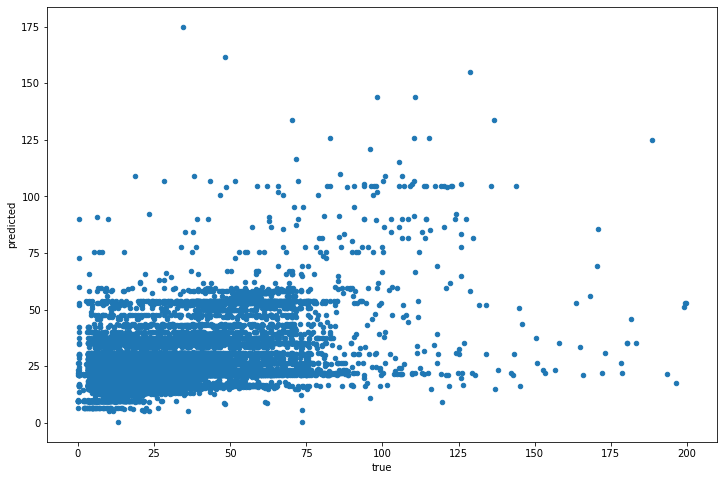

In [1]:
# start coding from here - load grouped data file size 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

taxi_grouped_by_region = pd.read_csv('data/taxi_grouped.csv')
taxi_grouped_by_region = taxi_grouped_by_region.drop(labels='Unnamed: 0', axis=1)

print(taxi_grouped_by_region[['transaction_date', 'transaction_month', 'transaction_day', 'transaction_hour']].dtypes)
data_for_benchmark_model = taxi_grouped_by_region.copy()

categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour']
input_features_benchmark = categorical_features_benchmark
target_features_benchmark = ['total_amount']

X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_features_benchmark]
X_bench.dtypes

# one-hot encode
X_bench = pd.get_dummies(X_bench)

# split data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)

# fit a model
tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train_b, y_train_b)

# model evaluation
model_at_hand = tree
y_pred_b = model_at_hand.predict(X_test_b)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

print(f'Mean absolute errror: {mean_absolute_error(y_test_b, y_pred_b):.5f}')
print(f'Mean squared errror: {mean_squared_error(y_test_b, y_pred_b):.5f}')
print(f'Root mean squared errror: {sqrt(mean_squared_error(y_test_b, y_pred_b)):.5f}')
print(f'R2 score: {r2_score(y_test_b, y_pred_b):.5f}')

data = {'true': y_test_b.iloc[:, 0], 'predicted': y_pred_b}
# test: DataFrame - predicted: numpy array

results = pd.DataFrame(data)
results.plot(kind='scatter', x='true', y='predicted', figsize=(12, 8))
plt.show()



# 6 Data engineering

In [2]:
taxi_grouped_by_region.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2019-01-01,1,1,2,0.0,21.800,1
1,1,2019-01-01,1,1,5,0.0,87.300,1
2,1,2019-01-01,1,1,6,0.0,80.300,1
3,1,2019-01-01,1,1,8,0.0,128.580,2
4,1,2019-01-01,1,1,10,16.9,43.245,4


In [3]:
data_with_new_features = taxi_grouped_by_region.copy()

Data related features

In [4]:
data_with_new_features['transaction_date'] = pd.to_datetime(data_with_new_features['transaction_date'])
data_with_new_features['transaction_week_day'] = data_with_new_features['transaction_date'].dt.weekday

print(f'Here the week starts from 0 which is Monday')
print(data_with_new_features['transaction_week_day'].value_counts().index)
data_with_new_features['weekend'] = data_with_new_features['transaction_week_day'].apply(lambda x: True if x == 5 | x == 6 else False)

Here the week starts from 0 which is Monday
Index([2, 3, 1, 4, 0, 5, 6], dtype='int32', name='transaction_week_day')


In [5]:
from pandas.tseries.holiday import USFederalHolidayCalendar
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2018', end='2020').date

# transforming numpy array of objects to the DataTime format
holidays = pd.to_datetime(holidays)

data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].isin(holidays)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True


Borough information

In [6]:
zone_lookup = pd.read_csv('data/taxi_zone_lookup.csv')
zone_lookup = zone_lookup[['LocationID', 'Borough']]
# zone_lookup['LocationID'] = zone_lookup['LocationID'].astype(str)

print(f"LocationID_type: {zone_lookup['LocationID'].dtype}")
print(f"PULocationID_type: {data_with_new_features['PULocationID'].dtype}")

zone_lookup.loc[264, 'Borough'] = 'Outside of NYC'
zone_lookup.tail()

LocationID_type: int64
PULocationID_type: int64


,LocationID,Borough
260,261,Manhattan
261,262,Manhattan
262,263,Manhattan
263,264,Unknown
264,265,Outside of NYC


In [7]:
data_with_new_features = data_with_new_features.merge(zone_lookup, left_on='PULocationID', right_on='LocationID', how='left')
data_with_new_features = data_with_new_features.drop(labels='LocationID', axis=1)
print(data_with_new_features.shape)
data_with_new_features.head()

(102556, 12)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True,EWR
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True,EWR
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True,EWR
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True,EWR
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True,EWR


In [8]:
print(data_with_new_features.isna().sum())
data_with_new_features['Borough'].value_counts(dropna=False)

PULocationID             0
transaction_date         0
transaction_month        0
transaction_day          0
transaction_hour         0
trip_distance            0
total_amount             0
count_of_transactions    0
transaction_week_day     0
weekend                  0
is_holiday               0
Borough                  0
dtype: int64


Borough
Manhattan         45309
Brooklyn          23633
Queens            22002
Bronx              9586
Unknown             744
Outside of NYC      709
Staten Island       302
EWR                 271
Name: count, dtype: int64

Weather related features

In [9]:
import requests
import pandas as pd

params = {
    'latitude': 40.7128,
    'longitude': -74.0060,
    'start_date': '2019-01-01',
    'end_date': '2019-01-31',
    'hourly': 'temperature_2m,relative_humidity_2m,cloudcover,windspeed_10m,precipitation',
    'timezone': 'America/New_York'
}

response = requests.get('https://archive-api.open-meteo.com/v1/archive', params=params)

print(response.json().keys())
print(response.json()['hourly'].keys())

if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data['hourly'], columns=['time', 'temperature_2m', 'relative_humidity_2m', 'windspeed_10m', 'cloudcover', 'precipitation'])
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    df_3H = df.resample('3h').agg({
        'temperature_2m': 'mean', 
        'relative_humidity_2m': 'mean', 
        'windspeed_10m': 'mean', 
        'cloudcover': 'mean', 
        'precipitation': 'sum'
    })

    df_3H.to_csv('data/nyc_weather_no_missing values.csv')
    print(f'\nWeather data file saved correctly - status code: {response.status_code}')

else:
    print(f'\nSomething went wrong - status code: {response.status_code}')

df_3H.head()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])
dict_keys(['time', 'temperature_2m', 'relative_humidity_2m', 'cloudcover', 'windspeed_10m', 'precipitation'])

Weather data file saved correctly - status code: 200


,temperature_2m,relative_humidity_2m,windspeed_10m,cloudcover,precipitation
time,,,,,
2019-01-01 00:00:00,8.700000,97.000000,16.100000,100.000000,7.1
2019-01-01 03:00:00,12.366667,94.333333,26.600000,99.000000,0.4
2019-01-01 06:00:00,13.600000,90.000000,29.633333,86.666667,0.0
2019-01-01 09:00:00,13.933333,74.333333,32.400000,99.000000,0.0
2019-01-01 12:00:00,11.500000,60.333333,33.400000,75.666667,0.0


In [10]:
index = pd.date_range('1/1/2000', periods=9, freq='h')
series = pd.Series(range(9), index=index)
print(series)

series.resample('3h').agg('sum')

2000-01-01 00:00:00    0
2000-01-01 01:00:00    1
2000-01-01 02:00:00    2
2000-01-01 03:00:00    3
2000-01-01 04:00:00    4
2000-01-01 05:00:00    5
2000-01-01 06:00:00    6
2000-01-01 07:00:00    7
2000-01-01 08:00:00    8
Freq: H, dtype: int64


2000-01-01 00:00:00     3
2000-01-01 03:00:00    12
2000-01-01 06:00:00    21
Freq: 3H, dtype: int64

In [11]:
# The source file has been modified to present how to deal with missing values, strings, etc
nyc_weather = pd.read_csv('data/nyc_weather_missing_values.csv')

# if there are NaN values at the beggining or end of DataFrame it would be not possible to use .interpolate()
# use .fillna(method='ffill', 'bfill') instead
nyc_weather.head()
nyc_weather.tail()

,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation
243,2019-01-31 09:00:00,-14.600000,35.333333,20.766667,no clouds,NaN
244,2019-01-31 12:00:00,-10.333333,26.666667,19.566667,no clouds,0.0
245,2019-01-31 15:00:00,-8.566667,25.666667,20.700000,no clouds,NaN
246,2019-01-31 18:00:00,-9.966667,32.666667,17.100000,no clouds,NaN
247,2019-01-31 21:00:00,-10.433333,31.333333,14.600000,no clouds,0.0


In [12]:
nyc_weather['cloud cover'].value_counts()

cloud cover
100%.           99
no clouds       55
70 – 80%.       36
20–30%.         28
50%.            22
??               1
weird_value1     1
undefined        1
broken_data      1
Name: count, dtype: int64

In [13]:
nyc_weather['amount of precipitation'].value_counts()

amount of precipitation
0.0                       125
Trace of precipitation     17
0.1                         6
0.4                         3
1.6                         2
0.2                         2
0.3                         2
7.1                         1
1.0                         1
1.9                         1
0.5                         1
10.3                        1
9.0                         1
5.7                         1
5.2                         1
0.8                         1
8.899999999999999           1
8.4                         1
3.0                         1
2.9                         1
1.8                         1
3.2                         1
6.4                         1
2.6                         1
Name: count, dtype: int64

In [14]:
nyc_weather.isna().sum()

date and time               0
temperature                 0
humidity                    0
wind speed                  0
cloud cover                 4
amount of precipitation    74
dtype: int64

Trace of precipitation can be thought of as 0.1\
And the missing values 0 ???\
to be considered

In [15]:
nyc_weather['amount of precipitation'] = nyc_weather['amount of precipitation'].replace('Trace of precipitation', 0.1)
nyc_weather['amount of precipitation'] = nyc_weather['amount of precipitation'] .astype(float)

# Dealing with the missing values

# option 1
# nyc_weather['amount of precipitation'].fillna(0, inplace=True)

# option 2
# nyc_weather['amount of precipitation'].fillna(method='bfill', inplace=True)

# option 3
nyc_weather['amount of precipitation'] = nyc_weather['amount of precipitation'].interpolate()

In [16]:
mapping = {
    '100%.': 1.0,
    'no clouds': 0.0,
    '70 – 80%.': 0.7,
    '20–30%.': 0.2,
    '50%.': 0.5,
    '??': pd.NA,
    'weird_value1': pd.NA,
    'undefined': pd.NA,
    'broken_data': pd.NA
}

nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace(mapping)
nyc_weather['cloud cover'] = pd.to_numeric(nyc_weather['cloud cover'], errors='coerce')
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].interpolate()

In [17]:
nyc_weather.head()
nyc_weather.isna().sum()

date and time              0
temperature                0
humidity                   0
wind speed                 0
cloud cover                0
amount of precipitation    0
dtype: int64

In [18]:
nyc_weather['date and time'] = pd.to_datetime(nyc_weather['date and time'])

nyc_weather['month'] = nyc_weather['date and time'].dt.month
nyc_weather['day'] = nyc_weather['date and time'].dt.day
nyc_weather['hour'] = nyc_weather['date and time'].dt.hour

nyc_weather.head(1)

,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation,month,day,hour
0,2019-01-01,8.7,97.0,16.1,1.0,7.1,1,1,0


In [19]:
data_with_new_features.tail(1)

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
102555,99,2019-01-30,1,30,11,31.6,99.32,1,2,False,False,Staten Island


In [20]:
data_with_new_features = (data_with_new_features.merge(nyc_weather,
    left_on=['transaction_month','transaction_day','transaction_hour'],
    right_on=['month','day','hour'],
    how='left')
    )
data_with_new_features = data_with_new_features.drop(columns=['date and time', 'month','day','hour'])

print(data_with_new_features.shape)
data_with_new_features.head()

(102556, 17)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough,temperature,humidity,wind speed,cloud cover,amount of precipitation
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True,EWR,NaN,NaN,NaN,NaN,NaN
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True,EWR,NaN,NaN,NaN,NaN,NaN
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True,EWR,13.6,90.0,29.633333,0.7,0.0
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True,EWR,NaN,NaN,NaN,NaN,NaN
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True,EWR,NaN,NaN,NaN,NaN,NaN


In [21]:
data_with_new_features.isna().sum()

PULocationID                   0
transaction_date               0
transaction_month              0
transaction_day                0
transaction_hour               0
trip_distance                  0
total_amount                   0
count_of_transactions          0
transaction_week_day           0
weekend                        0
is_holiday                     0
Borough                        0
temperature                68478
humidity                   68478
wind speed                 68478
cloud cover                68478
amount of precipitation    68478
dtype: int64

In [22]:
data_with_new_features.head()
data_with_new_features.tail(7)

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough,temperature,humidity,wind speed,cloud cover,amount of precipitation
102549,98,2019-01-31,1,31,12,3.08,13.30,1,3,False,False,Queens,-10.333333,26.666667,19.566667,0.0,0.0
102550,98,2019-01-31,1,31,13,10.85,38.35,2,3,False,False,Queens,NaN,NaN,NaN,NaN,NaN
102551,98,2019-01-31,1,31,18,16.66,58.06,1,3,False,False,Queens,-9.966667,32.666667,17.100000,0.0,0.0
102552,99,2019-01-18,1,18,18,1.66,9.80,1,4,False,False,Staten Island,0.966667,86.000000,7.933333,1.0,0.1
102553,99,2019-01-26,1,26,8,0.42,6.00,1,5,False,False,Staten Island,NaN,NaN,NaN,NaN,NaN
102554,99,2019-01-30,1,30,7,2.87,18.05,1,2,False,False,Staten Island,NaN,NaN,NaN,NaN,NaN
102555,99,2019-01-30,1,30,11,31.60,99.32,1,2,False,False,Staten Island,NaN,NaN,NaN,NaN,NaN


In [23]:
data_with_new_features.isna().sum()

PULocationID                   0
transaction_date               0
transaction_month              0
transaction_day                0
transaction_hour               0
trip_distance                  0
total_amount                   0
count_of_transactions          0
transaction_week_day           0
weekend                        0
is_holiday                     0
Borough                        0
temperature                68478
humidity                   68478
wind speed                 68478
cloud cover                68478
amount of precipitation    68478
dtype: int64

In [24]:
# before filling in the missing values it is necessary to sort the data by date and hour
data_with_new_features = data_with_new_features.sort_values(by=['transaction_date', 'transaction_hour']).reset_index(drop=True)

data_with_new_features.head()
data_with_new_features.tail()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough,temperature,humidity,wind speed,cloud cover,amount of precipitation
102551,88,2019-01-31,1,31,23,5.196607,27.126607,56,3,False,False,Manhattan,NaN,NaN,NaN,NaN,NaN
102552,89,2019-01-31,1,31,23,1.750000,9.050000,2,3,False,False,Brooklyn,NaN,NaN,NaN,NaN,NaN
102553,90,2019-01-31,1,31,23,2.967793,16.049718,213,3,False,False,Manhattan,NaN,NaN,NaN,NaN,NaN
102554,94,2019-01-31,1,31,23,0.590000,5.800000,1,3,False,False,Bronx,NaN,NaN,NaN,NaN,NaN
102555,97,2019-01-31,1,31,23,3.215263,15.602105,19,3,False,False,Brooklyn,NaN,NaN,NaN,NaN,NaN


In [25]:
data_with_new_features = data_with_new_features.fillna(method='ffill')
data_with_new_features.tail()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough,temperature,humidity,wind speed,cloud cover,amount of precipitation
102551,88,2019-01-31,1,31,23,5.196607,27.126607,56,3,False,False,Manhattan,-10.433333,31.333333,14.6,0.0,0.0
102552,89,2019-01-31,1,31,23,1.750000,9.050000,2,3,False,False,Brooklyn,-10.433333,31.333333,14.6,0.0,0.0
102553,90,2019-01-31,1,31,23,2.967793,16.049718,213,3,False,False,Manhattan,-10.433333,31.333333,14.6,0.0,0.0
102554,94,2019-01-31,1,31,23,0.590000,5.800000,1,3,False,False,Bronx,-10.433333,31.333333,14.6,0.0,0.0
102555,97,2019-01-31,1,31,23,3.215263,15.602105,19,3,False,False,Brooklyn,-10.433333,31.333333,14.6,0.0,0.0


In [26]:
data_with_new_features.isna().sum()

PULocationID               0
transaction_date           0
transaction_month          0
transaction_day            0
transaction_hour           0
trip_distance              0
total_amount               0
count_of_transactions      0
transaction_week_day       0
weekend                    0
is_holiday                 0
Borough                    0
temperature                0
humidity                   0
wind speed                 0
cloud cover                0
amount of precipitation    0
dtype: int64

In [34]:
def f(x, y):
    print(f'x,y={x}, {y}')
    return x**2 + y**2

a = np.array([2, 3])

val = [f(*a)]

print(f'val={val}')

x,y=2, 3
val=[13]


k	 (x_k, y_k)		 f(x_k, y_k)
0	 (2.000000, 1.500000)	 6.250000
1	 (1.600000, 1.200000)	 4.000000
2	 (1.280000, 0.960000)	 2.560000
3	 (1.024000, 0.768000)	 1.638400
4	 (0.819200, 0.614400)	 1.048576
5	 (0.655360, 0.491520)	 0.671089
6	 (0.524288, 0.393216)	 0.429497
7	 (0.419430, 0.314573)	 0.274878
8	 (0.335544, 0.251658)	 0.175922
9	 (0.268435, 0.201327)	 0.112590
10	 (0.214748, 0.161061)	 0.072058
11	 (0.171799, 0.128849)	 0.046117
12	 (0.137439, 0.103079)	 0.029515
13	 (0.109951, 0.082463)	 0.018889
14	 (0.087961, 0.065971)	 0.012089
15	 (0.070369, 0.052777)	 0.007737
16	 (0.056295, 0.042221)	 0.004952
17	 (0.045036, 0.033777)	 0.003169
18	 (0.036029, 0.027022)	 0.002028
19	 (0.028823, 0.021617)	 0.001298
20	 (0.023058, 0.017294)	 0.000831


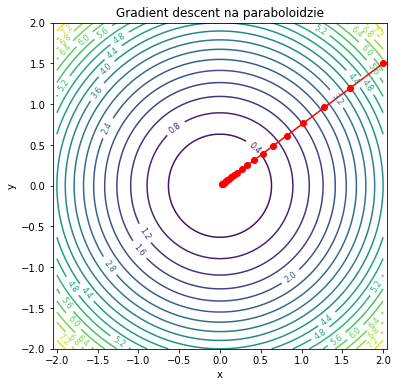

In [32]:
# gradient_descent_2d.py
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return np.array([2*x, 2*y])

def gradient_descent(x0, eta, n_iter):
    points = [x0]
    values = [f(*x0)]
    x = np.array(x0, dtype=float)
    for k in range(n_iter):
        x = x - eta * grad_f(*x)
        points.append(x.copy())
        values.append(f(*x))
    return np.array(points), np.array(values)

if __name__ == "__main__":
    # parametry startowe
    x0 = np.array([2.0, 1.5])
    eta = 0.1
    n_iter = 20

    points, values = gradient_descent(x0, eta, n_iter)

    # wypisz pierwsze iteracje
    print("k\t (x_k, y_k)\t\t f(x_k, y_k)")
    for k in range(len(points)):
        print(f"{k}\t ({points[k][0]:.6f}, {points[k][1]:.6f})\t {values[k]:.6f}")

    # rysunek powierzchni + trajektoria
    X, Y = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
    Z = f(X, Y)

    fig, ax = plt.subplots(figsize=(6,6))
    # poziomice
    cs = ax.contour(X, Y, Z, levels=20, cmap='viridis')
    ax.clabel(cs, inline=True, fontsize=8)

    # trajektoria kroków
    ax.plot(points[:,0], points[:,1], marker='o', color='red')
    ax.set_title("Gradient descent na paraboloidzie")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    plt.show()


In [28]:
# compare_eta.py
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return np.array([2*x, 2*y])

def gradient_descent_path(x0, eta, n_iter=200, tol=1e-6):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    values = [f(*x)]
    for k in range(n_iter):
        x = x - eta * grad_f(*x)
        path.append(x.copy())
        values.append(f(*x))
        if values[-1] < tol:
            break
    return np.array(path), np.array(values), k+1  # k+1 = liczba wykonanych iteracji

def compare_etas(x0, etas, n_iter=500, tol=1e-8):
    results = []
    all_paths = {}
    all_values = {}
    for eta in etas:
        path, values, iters = gradient_descent_path(x0, eta, n_iter=n_iter, tol=tol)
        final_val = values[-1]
        results.append({'eta': eta, 'iters': iters, 'final_val': final_val, 'last_point': path[-1]})
        all_paths[eta] = path
        all_values[eta] = values
    return results, all_paths, all_values

def print_results_table(results):
    print("eta\titers\tfinal f(x,y)\t\t last point (x,y)")
    for r in results:
        print(f"{r['eta']}\t{r['iters']}\t{r['final_val']:.6e}\t ({r['last_point'][0]:.6f}, {r['last_point'][1]:.6f})")

def plot_contours_with_paths(all_paths, savefile="gd_paths_comparison.png"):
    # siatka poziomic
    limit = 2.5
    X, Y = np.meshgrid(np.linspace(-limit, limit, 300), np.linspace(-limit, limit, 300))
    Z = X**2 + Y**2

    fig, ax = plt.subplots(figsize=(7,7))
    cs = ax.contour(X, Y, Z, levels=30)
    ax.clabel(cs, inline=True, fontsize=8)

    for eta, path in all_paths.items():
        ax.plot(path[:,0], path[:,1], marker='o', label=f"eta={eta}", markersize=4, linewidth=1)
        # punkt startowy (duży)
        ax.scatter(path[0,0], path[0,1], s=60, edgecolors='k', linewidths=0.8)

    ax.set_title("Porównanie trajektorii GD dla różnych eta")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis('equal')
    ax.legend()
    plt.tight_layout()
    plt.savefig(savefile, dpi=200)
    plt.close(fig)
    print(f"Zapisano wykres trajektorii do: {savefile}")

def plot_values_over_iters(all_values, savefile="gd_values_comparison.png"):
    fig, ax = plt.subplots(figsize=(8,4))
    for eta, values in all_values.items():
        ax.semilogy(values, marker='o', markersize=4, label=f"eta={eta}")
    ax.set_xlabel("iteracja k")
    ax.set_ylabel("f(x_k,y_k) (log scale)")
    ax.set_title("Spadek wartości funkcji w czasie dla różnych eta")
    ax.legend()
    plt.tight_layout()
    plt.savefig(savefile, dpi=200)
    plt.close(fig)
    print(f"Zapisano wykres wartości funkcji do: {savefile}")

if __name__ == "__main__":
    # punkt startowy
    x0 = np.array([2.0, 1.5])

    # wartości eta do porównania
    etas = [0.05, 0.1, 0.5]

    # parametry eksperymentu
    max_iter = 500
    tol = 1e-8

    results, all_paths, all_values = compare_etas(x0, etas, n_iter=max_iter, tol=tol)

    # wypisz tabelę wyników
    print_results_table(results)

    # zapisz wykresy (kontury + trajektorie; oraz spadek wartości funkcji)
    plot_contours_with_paths(all_paths, savefile="gd_paths_comparison.png")
    plot_values_over_iters(all_values, savefile="gd_values_comparison.png")

    # dodatkowo zapisz dane trajektorii do pliku .npz
    np.savez("gd_compare_data.npz", **{f"path_eta_{eta}": all_paths[eta] for eta in all_paths})
    print("Zapisano dane trajektorii do: gd_compare_data.npz")


eta	iters	final f(x,y)		 last point (x,y)
0.05	97	8.297110e-09	 (0.000073, 0.000055)
0.1	46	7.588550e-09	 (0.000070, 0.000052)
0.5	1	0.000000e+00	 (0.000000, 0.000000)
Zapisano wykres trajektorii do: gd_paths_comparison.png
Zapisano wykres wartości funkcji do: gd_values_comparison.png
Zapisano dane trajektorii do: gd_compare_data.npz
